In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import cv2
from tqdm import tqdm
import os
import random
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from transformers import AutoImageProcessor, TimesformerForVideoClassification
import torch


c:\Users\parth\.pyenv-win-venv\envs\capdis_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_video_frames_opencv(video_path, num_frames=20):
    cap = cv2.VideoCapture(video_path)
    try:
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        if total_frames < num_frames:
            raise ValueError(f"Video too short: {total_frames} < {num_frames}")

        frame_indices = set()
        attempts = 0
        while len(frame_indices) < num_frames and attempts < 3:
            offsets = np.linspace(0, total_frames-1, num_frames-len(frame_indices))
            frame_indices.update(int(round(o)) for o in offsets)
            attempts += 1

        frames = []
        for idx in sorted(frame_indices):
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        
        cap.release()
        
        if len(frames) < num_frames:
            last_frame = frames[-1]
            frames += [last_frame] * (num_frames - len(frames))

        video_tensor = torch.tensor(np.array(frames), dtype=torch.float32).permute(0, 3, 1, 2)
        video_tensor /= 255.0

        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                            std=[0.229, 0.224, 0.225])
        ])
        
        return transform(video_tensor)  # [T, C, H, W]
    finally:
        cap.release()


In [3]:
def extract_label(path):
  return path.split('/')[2]

In [4]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

image_processor = AutoImageProcessor.from_pretrained("MCG-NJU/videomae-base-finetuned-kinetics")

model = TimesformerForVideoClassification.from_pretrained("facebook/timesformer-base-finetuned-k400",trust_remote_code=True,
    use_safetensors=True)
model.eval().to(device)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


TimesformerForVideoClassification(
  (timesformer): TimesformerModel(
    (embeddings): TimesformerEmbeddings(
      (patch_embeddings): TimesformerPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (time_drop): Dropout(p=0.0, inplace=False)
    )
    (encoder): TimesformerEncoder(
      (layer): ModuleList(
        (0-11): 12 x TimesformerLayer(
          (drop_path): Identity()
          (attention): TimeSformerAttention(
            (attention): TimesformerSelfAttention(
              (qkv): Linear(in_features=768, out_features=2304, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
            )
            (output): TimesformerSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): TimesformerIntermediate(
            (dense

In [5]:
video_folder = "data/"
data = {}
video_paths,labels = [],[]
for root, _, files in os.walk(video_folder):
    for f in files:
        if f.endswith((".mp4", ".avi")):
            path=os.path.join(root, f).replace("\\", "/")
            data[path] = extract_label(path)
            # video_paths.append(path)
            # labels.append(extract_label(path))


In [6]:
from collections import defaultdict
label_to_paths = defaultdict(list)

for path, label in data.items():
    label_to_paths[label].append(path)
balanced_sample = {}
for label, paths in label_to_paths.items():
    num_samples = min(200, len(paths))
    selected_paths = random.sample(paths, num_samples)
    for path in selected_paths:
        balanced_sample[path] = label

In [7]:
# idxs = [random.randint(1, len(labels)) for i in range(100)]
# video_paths, labels = [video_paths[x] for x in idxs], [labels[x] for x in idxs]
# len(video_paths), len(labels)

In [8]:
video_paths, labels = list(balanced_sample.keys()), list(balanced_sample.values())

In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    video_paths, labels, test_size=0.2, random_state=42, stratify=labels
)
len(X_train), len(X_val), len(y_train), len(y_val)

(1600, 400, 1600, 400)

In [10]:
# X_train, X_val, y_train, y_val = video_paths[5:], video_paths[:5], labels[5:], labels[:5]
# len(X_train), len(X_val), len(y_train), len(y_val)

In [11]:
for label in set(labels):
    print(f"{label}: {labels.count(label)}")

substitution: 200
freekick: 200
goalkick: 200
foul: 200
shortpass: 200
longpass: 200
penalty: 200
ontarget: 200
throw-in: 200
corner: 200


In [12]:
y_train_encoded, uniques = pd.factorize(y_train)
y_val_encoded = pd.Series(y_val).map({label: idx for idx, label in enumerate(uniques)}).values

C:\Users\parth\AppData\Local\Temp\ipykernel_24384\4134361369.py:1: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  y_train_encoded, uniques = pd.factorize(y_train)


In [13]:
class VideoDataset(Dataset):
    def __init__(self, video_paths, labels, num_frames=20):
        self.video_paths = video_paths
        self.labels = labels
        self.num_frames = num_frames

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        path = self.video_paths[idx]
        label = self.labels[idx]
        frames = load_video_frames_opencv(path, num_frames=self.num_frames)
        return frames, label

In [14]:
train_dataset = VideoDataset(X_train, y_train_encoded, num_frames=20)
val_dataset = VideoDataset(X_val, y_val_encoded, num_frames=20)

In [15]:
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

Feature batch shape: torch.Size([1, 20, 3, 224, 224])
Labels batch shape: torch.Size([1])


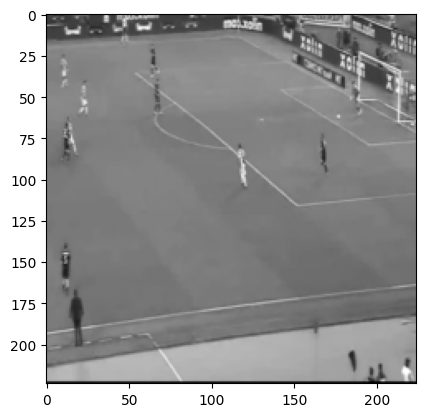

Label: 9


In [16]:
train_features, train_labels = next(iter(train_loader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img[0][1], cmap="gray")
plt.show()
print(f"Label: {label}")

Significant imporvement upon 2nd epoch, try 3-4 more

In [17]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = torch.nn.CrossEntropyLoss()
num_epochs=3
model.train()
for epoch in range(num_epochs):
    epoch_loss = 0.0
    num_batches = 0
    for batch_x, batch_y in tqdm(train_loader):
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x).logits
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        num_batches += 1
        del batch_x, batch_y, outputs, loss
        torch.cuda.empty_cache()
    print(f"Epoch {epoch + 1}, Loss: {epoch_loss / num_batches:.4f}")


100%|██████████| 1600/1600 [31:35<00:00,  1.18s/it]


Epoch 1, Loss: 1.5292


100%|██████████| 1600/1600 [33:02<00:00,  1.24s/it]


Epoch 2, Loss: 0.7824


100%|██████████| 1600/1600 [35:08<00:00,  1.32s/it]

Epoch 3, Loss: 0.5223


In [18]:
from sklearn.metrics import classification_report
import torch

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in tqdm(val_loader):
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        outputs = model(batch_x).logits
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())
        del batch_x, batch_y, outputs, preds
        torch.cuda.empty_cache()

        

# Generate classification report
report = classification_report(all_labels, all_preds, digits=4)
print(report)


100%|██████████| 400/400 [04:25<00:00,  1.50it/s]

              precision    recall  f1-score   support

           0     0.8095    0.4250    0.5574        40
           1     0.8636    0.9500    0.9048        40
           2     0.8462    0.5500    0.6667        40
           3     0.8333    0.8750    0.8537        40
           4     0.3140    0.9500    0.4720        40
           5     0.5342    0.9750    0.6903        40
           6     1.0000    0.0500    0.0952        40
           7     0.9167    0.8250    0.8684        40
           8     1.0000    0.2500    0.4000        40
           9     1.0000    0.6250    0.7692        40

    accuracy                         0.6475       400
   macro avg     0.8118    0.6475    0.6278       400
weighted avg     0.8118    0.6475    0.6278       400



In [19]:
model.save_pretrained('./finetuned_model')